In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, norm
import json

Total de estudantes: 1000
Média: -0.0063
Desvio padrão: 0.9720
Min: -2.9726
Max: 2.7804


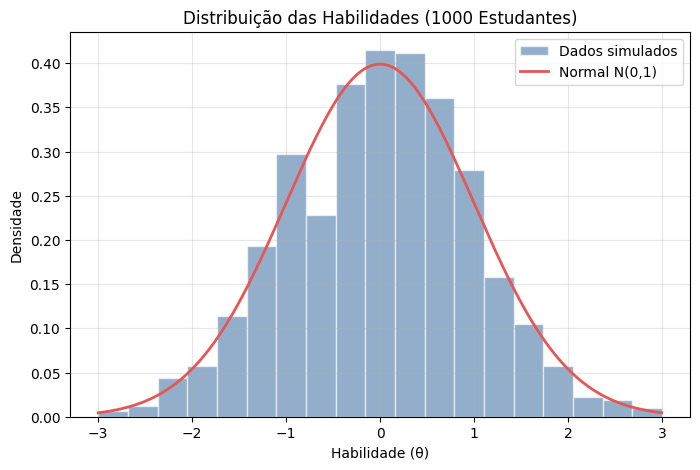

In [5]:
# carregar JSON
with open("batches_estudantes.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# extrair todas as habilidades
todas_habilidades = []

for batch in data["batches"]:
    for student in batch["estudantes"]:
        todas_habilidades.append(student["habilidade"])

# transformar em array
todas_habilidades = np.array(todas_habilidades)

# estatísticas
print(f"Total de estudantes: {len(todas_habilidades)}")
print(f"Média: {np.mean(todas_habilidades):.4f}")
print(f"Desvio padrão: {np.std(todas_habilidades):.4f}")
print(f"Min: {np.min(todas_habilidades):.4f}")
print(f"Max: {np.max(todas_habilidades):.4f}")

# -----------------------
# PLOT
# -----------------------

plt.figure(figsize=(8,5))

# histograma
plt.hist(
    todas_habilidades,
    bins=np.linspace(-3,3,20),
    density=True,
    alpha=0.6,
    color="#4C78A8",
    edgecolor="white",
    label="Dados simulados"
)

# curva normal teórica
x = np.linspace(-3,3,200)
plt.plot(
    x,
    norm.pdf(x, 0, 1),
    color="#E45756",
    linewidth=2,
    label="Normal N(0,1)"
)

plt.title("Distribuição das Habilidades (1000 Estudantes)")
plt.xlabel("Habilidade (θ)")
plt.ylabel("Densidade")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [9]:
todas_habilidades.shape

(1000,)

### Gerando 1000 direto


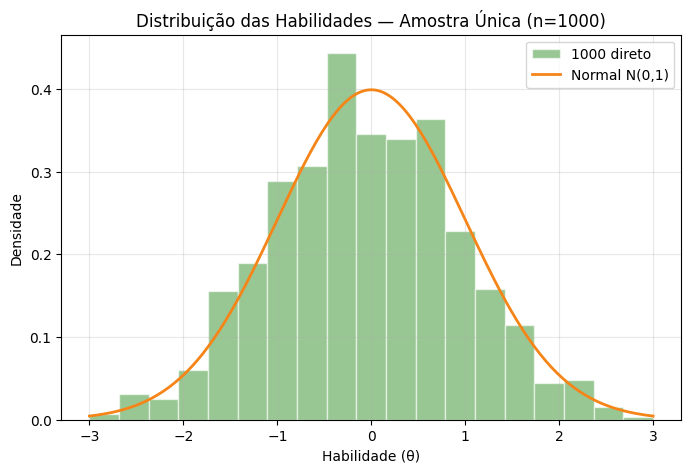

{
  "students": [
    {
      "id_estudante": "1",
      "habilidade": 0.5701
    },
    {
      "id_estudante": "2",
      "habilidade": 0.8643
    },
    {
      "id_estudante": "3",
      "habilidade": 0.6932
    },
    {
      "id_estudante": "4",
      "habilidade": 0.416
    },
    {
      "id_estudante": "5",
      "habilidade": -0.7687
    },
    {
      "id_estudante": "6",
      "habilidade": 2.1042
    },
    {
      "id_estudante": "7",
      "habilidade": -2.176
    },
    {
      "id_estudante": "8",
      "habilidade": 1.1753
    },
    {
      "id_estudante": "9",
      "habilidade": 0.7616
    },
    {
      "id_estudante": "10",
      "habilidade": -0.2847
    },
    {
      "id_estudante": "11",
      "habilidade": -0.6029
    },
    {
      "id_estudante": "12",
      "habilidade": 0.5696
    },
    {
      "id_estudante": "13",
      "habilidade": -0.181
    },
    {
      "id_estudante": "14",
      "habilidade": -0.2129
    },
    {
      "id_estudante": "15",
  

In [19]:
# parâmetros
NUM_ESTUDANTES = 1000

media = 0
desvio_padrao = 1
limite_inferior = -3
limite_superior = 3

# normal truncada
a = (limite_inferior - media) / desvio_padrao
b = (limite_superior - media) / desvio_padrao

# gerar 1000 direto
dados = truncnorm.rvs(a, b, loc=media, scale=desvio_padrao, size=NUM_ESTUDANTES)

# criar lista de estudantes
students = [
    {
        "id_estudante": str(i + 1),
        "habilidade": round(float(theta), 4)
    }
    for i, theta in enumerate(dados)
]

# -----------------------
# PLOT (cor diferente)
# -----------------------

plt.figure(figsize=(8,5))

# histograma (verde pra diferenciar)
plt.hist(
    dados,
    bins=np.linspace(-3,3,20),
    density=True,
    color="#54A24B",  # verde
    alpha=0.6,
    edgecolor="white",
    label="1000 direto"
)

# curva normal
x = np.linspace(-3,3,200)
plt.plot(
    x,
    norm.pdf(x,0,1),
    color="#F58518",  # laranja
    linewidth=2,
    label="Normal N(0,1)"
)

plt.title("Distribuição das Habilidades — Amostra Única (n=1000)")
plt.xlabel("Habilidade (θ)")
plt.ylabel("Densidade")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# -----------------------
# JSON (sem batches)
# -----------------------

students_json = {
    "students": students
}

print(json.dumps(students_json, indent=2))